<a href="https://colab.research.google.com/github/giumont/overlap_resolver/blob/main/notebooks/Transformer_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORT FILE DATI DA GOOGLE

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [25]:
# IMPORT GITHUB REPO: flavour_tag_ml (repo "flavour_tagging")

from google.colab import userdata
import os
import sys

token = userdata.get("GITHUB_TOKEN")

REPO_PATH_FLAVOUR_TAG_ML = "/content/flavour_tagging"

if not os.path.exists(REPO_PATH_FLAVOUR_TAG_ML):
    !git clone https://{token}@github.com/giumont/flavour_tagging.git {REPO_PATH_FLAVOUR_TAG_ML}
else:
    !git -C {REPO_PATH_FLAVOUR_TAG_ML} pull --rebase

# The importable package lives under <repo>/src/flavour_tag_ml, so we add
# <repo>/src (not the repo root) to sys.path and import it as a top-level
# package: "import flavour_tag_ml".
SRC_PATH_FLAVOUR_TAG_ML = os.path.join(REPO_PATH_FLAVOUR_TAG_ML, "src")
if SRC_PATH_FLAVOUR_TAG_ML not in sys.path:
    sys.path.append(SRC_PATH_FLAVOUR_TAG_ML)

import flavour_tag_ml


remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 404 bytes | 404.00 KiB/s, done.
From https://github.com/giumont/flavour_tagging
   dc7b25d..72162dd  main       -> origin/main
Updating dc7b25d..72162dd
Fast-forward
 src/flavour_tag_ml/models.py | 1 +
 1 file changed, 1 insertion(+)


In [24]:
# IMPORT GITHUB REPO: overlap_resolver
#
# Contains, under "src/": obj_3_1.py, overlap_kinematics.py,
# truth_vs_reco_params.py and overlap_pairs_dataset_builder.py (this
# notebook's main orchestrator).

token_overlap = userdata.get("GITHUB_TOKEN_OVERLAP_RESOLVER")

REPO_PATH_OVERLAP_RESOLVER = "/content/overlap_resolver"

if not os.path.exists(REPO_PATH_OVERLAP_RESOLVER):
    !git clone https://{token_overlap}@github.com/giumont/overlap_resolver.git {REPO_PATH_OVERLAP_RESOLVER}
else:
    !git -C {REPO_PATH_OVERLAP_RESOLVER} pull --rebase

# Unlike flavour_tag_ml, the modules under overlap_resolver/src are FLAT:
# they import each other directly (e.g. overlap_kinematics.py does
# "from obj_3_1 import ..." and "from truth_vs_reco_params import ...",
# NOT "from src.obj_3_1 import ..."). To keep them working unmodified, we
# append the "src" folder ITSELF to sys.path (not the repo root), and
# import them below as flat top-level modules.
SRC_PATH_OVERLAP_RESOLVER = os.path.join(REPO_PATH_OVERLAP_RESOLVER, "src")
if SRC_PATH_OVERLAP_RESOLVER not in sys.path:
    sys.path.append(SRC_PATH_OVERLAP_RESOLVER)


Already up to date.


In [26]:
# IMPORT FILE PROGETTO DA GITHUB

from flavour_tag_ml.data import JetDataset, build_jet_features, extract_balanced_subset, compute_feature_stats
from flavour_tag_ml.merge_datasets import merge_checkpoint_chunks, check_checkpoint_progress

from flavour_tag_ml.models import create_model
from flavour_tag_ml.training import CategoricalFocalLoss, run_epoch, get_predictions, train_model, create_dataloaders

from flavour_tag_ml.utils import set_seed, load_mmap, save_run_outputs, build_metrics_report, run_evaluation_suite

In [27]:
# To reload imported files if they have been modified during runtime

import importlib
import flavour_tag_ml.data
import flavour_tag_ml.models
import flavour_tag_ml.training
import flavour_tag_ml.graphics
import flavour_tag_ml.utils

importlib.reload(flavour_tag_ml.data)
importlib.reload(flavour_tag_ml.merge_datasets)
importlib.reload(flavour_tag_ml.models)
importlib.reload(flavour_tag_ml.training)
importlib.reload(flavour_tag_ml.graphics)
importlib.reload(flavour_tag_ml.utils)

#from flavour_tag_ml.utils import build_jet_features

<module 'flavour_tag_ml.utils' from '/content/flavour_tagging/src/flavour_tag_ml/utils.py'>

In [19]:
# IMPORT PYTHON LIBRARIES

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [13]:
#################################################################
# GLOBAL PARAMS
#################################################################

# FILES
#DATASETS_DIR = '/content/' #gpu
INPUT_DIR = "/content/drive/MyDrive/overlap_resolver/datas/np_arrays/HH_bbtt" #cpu
#INPUT_DIR = "/content/drive/MyDrive/overlap_resolver/datas/np_arrays/bkg_tt" #cpu


TRAINSET_X_NAME = 'X_train_normalized.npy'
TRAINSET_Y_NAME = 'y_train_normalized.npy'

VALSET_X_NAME   = 'X_val_normalized.npy'
VALSET_Y_NAME   = 'y_val_normalized.npy'

TESTSET_X_NAME  = 'X_test_normalized.npy'
TESTSET_Y_NAME = 'y_test_normalized.npy'

#CHECK_LOAD_FILENAME = 'train_normalization_params.npz' # file with weights and feature_names (available for full, not reduced dataset)
CHECK_LOAD_FILENAME = "pair_feature_names.npz"

# DATASET
N_TRAIN = None
N_VAL   = None
N_TEST  = None

# OUTPUT_DIR = '/content/drive/MyDrive/flavour_tagging/obj_2/datas/np_arrays/MC23G_dataset'
# os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_DIR = None

SUB_TRAINSET_NAME = None
SUB_VALSET_NAME = None
SUB_TESTSET_NAME = None

# PROBLEM DEFINITION
NUM_CLASSES = 4 # FF=0, FT=1, TF=2, TT=3
CLASS_NAMES = ["FF", "FT", "TF", "TT"]  # ordine coerente con le label 0,1,2,3

TASK = "multiclass" if NUM_CLASSES > 2 else "binary"

# RETE
HIDDEN_DIMS = (32, 16)

ACTIV_FUNC = nn.GELU()
NORM_LAYER = nn.LayerNorm

DROPOUT = 0.1 # percentuale neuroni disattivati randomicamente: riduce overfitting

#################################################################
# MODEL CONFIG - SetTransformerTagger (alternativa a MLPMultiTagger)
#################################################################

# Raggruppamento delle 21 feature di FEATURE_KEYS (vedi notebook di
# preprocessing) in 4 token, secondo la loro origine fisica:
FEATURE_GROUPS = [
    [0, 1, 2, 3],                   # pair:  pair_dr, pair_deta, pair_dphi, pair_pt_ratio
    [4, 5, 6, 7, 8, 9],             # jet:   jet_pt, jet_eta, jet_phi, jet_mass, jet_n_muons, jet_gn2_score
    [10, 11, 12, 13, 14, 15, 16, 17, 18],  # tau: tau_pt, tau_eta, tau_phi, tau_nProng, tau_decayMode,
                                            #      tau_charge, tau_gn_score, tau_rnn_jet_score, tau_rnn_ele_score
    [19, 20],                       # met:   tau_met_proj, tau_mt
]

# Sanity check: la partizione deve coprire esattamente le colonne di X_train,
# nell'ordine di FEATURE_KEYS usato nel preprocessing.
assert sorted(i for g in FEATURE_GROUPS for i in g) == list(range(X_train.shape[1])), (
    "FEATURE_GROUPS non copre correttamente le colonne di X_train: "
    "verifica che l'ordine coincida con FEATURE_KEYS del notebook di preprocessing."
)

# RETE - Transformer
D_MODEL = 32       # stessa scala di HIDDEN_DIMS=(32,16) della MLP, per confronto equo
N_HEADS = 4        # d_model/n_heads = 8: dimensione per-head ragionevole con soli 4 token
N_LAYERS = 2        # stessa profondità (in "blocchi") della MLP a 2 hidden layer

MODEL_CONFIG = {
    "name": "SetTransformerTagger",
    "feature_groups": FEATURE_GROUPS,
    "num_classes": NUM_CLASSES,
    "d_model": D_MODEL,
    "n_heads": N_HEADS,
    "n_layers": N_LAYERS,
    "dropout": DROPOUT,   # stesso DROPOUT=0.1 già definito sopra
}

# TRAINING
BEST_MODEL_FOR_VALIDATION = True # False: salva a prescindere i weights dell'ultima epoca; True: previene overfitting
BEST_MODEL_METRIC = "ap_macro" # "mean" / "median" / "f1_macro" / "ap_macro": quale metrica su val viene considerata per aggiornare best_model

SAMPLING_STRATEGY = "none" # "none" / "oversample" / "undersample"

CRITERION = CategoricalFocalLoss()
WEIGHTED_LOSS = True

LR = 1e-3 # learning rate ottimizzatore
WEIGHT_DECAY = 1e-4  # regolarizzazione L2 nell'ottimizzatore

OPTIMIZER_CONFIG = {
    "name": "AdamW",
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
}

SCHEDULER_FACTOR = 0.7
SCHEDULER_PATIENCE = 5

SCHEDULER_CONFIG = {
    "name": "ReduceLROnPlateau",
    "factor": SCHEDULER_FACTOR,
    "patience": SCHEDULER_PATIENCE,
    "mode": "max"   # "max" must be used with "f1_macro" / "ap_macro" metrics
}

BATCH_SIZE = 2048
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 10

MIN_DELTA_VAL_LOSS = 1e-4 # soglia minima miglioramento loss su valset tra due epoche

# Suffisso comune per i nomi dei file salvati (architettura + training)
RUN_TAG = (
    f"transformer_{N_LAYERS}layers_dmodel{D_MODEL}_heads{N_HEADS}_"
    f"dropout{DROPOUT}_batch{BATCH_SIZE}"
    f"_lr{LR}_wd{WEIGHT_DECAY}"
    f"_best_on_{BEST_MODEL_METRIC}"
    f"_criterion_{CRITERION}"
    f"_weight_loss_{WEIGHTED_LOSS}"
    f"_sampling_strategy_{SAMPLING_STRATEGY}"
)

# Store weights: nome/percorso generati automaticamente da RUN_TAG,
MODEL_DIR = '/content/drive/MyDrive/overlap_resolver/models/HH_bbtt_dataset'
#MODEL_DIR = '/content/drive/MyDrive/overlap_resolver/models/bkg_tt_dataset'

os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_NAME = f"best_model_{RUN_TAG}.pt"
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)

CHECKPOINT_NAME = f"checkpoint_{RUN_TAG}.pt"
CHECKPOINT_PATH = os.path.join(MODEL_DIR, CHECKPOINT_NAME)

# GRAPHICS
GRAPHICS_DIR = "/content/drive/MyDrive/overlap_resolver/graphics/model_eval/HH_bbtt_dataset"
#GRAPHICS_DIR = "/content/drive/MyDrive/overlap_resolver/graphics/model_eval/bkg_tt_dataset"
os.makedirs(GRAPHICS_DIR, exist_ok=True)

# GITHUB
#GIT_OUTPUT_DIR = "DNN/HH_bbtt_dataset"
#GIT_OUTPUT_DIR = "DNN/bkg_tt_dataset"
GIT_OUTPUT_DIR = "Transformer/HH_bbtt_dataset"

# OTHER
RANDOM_SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
# SET GLOBAL SEED
set_seed(RANDOM_SEED)

In [ ]:
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
Device: cuda
GPU: Tesla T4


In [11]:
# LOADING INPUT

X_train = load_mmap(INPUT_DIR, TRAINSET_X_NAME)
y_train = load_mmap(INPUT_DIR, TRAINSET_Y_NAME)

X_val = load_mmap(INPUT_DIR, VALSET_X_NAME)
y_val = load_mmap(INPUT_DIR, VALSET_Y_NAME)

X_test = load_mmap(INPUT_DIR, TESTSET_X_NAME)
y_test = load_mmap(INPUT_DIR, TESTSET_Y_NAME)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(377567, 21) (377567,)
(80923, 21) (80923,)
(81083, 21) (81083,)


In [14]:
# WEIGHTS PER LOSS PESATA - GESTIONE IMBALANCE CLASSI

if WEIGHTED_LOSS:
  # Class weighting per gestire l'imbalance (FF 10.1%, FT 73.1%, TF 16.1%, TT 0.65%).
  # Calcolati SOLO sul train set (mai su val/test).
  train_class_counts = torch.bincount(torch.as_tensor(y_train, dtype=torch.long), minlength=NUM_CLASSES).float()
  CLASS_WEIGHTS = train_class_counts.sum() / (NUM_CLASSES * train_class_counts)
  CLASS_WEIGHTS = CLASS_WEIGHTS.to(DEVICE)

  if isinstance(CRITERION, nn.CrossEntropyLoss):
    CRITERION.weight=CLASS_WEIGHTS
  elif isinstance(CRITERION, CategoricalFocalLoss):
    CRITERION.alpha=CLASS_WEIGHTS
  else:
    raise ValueError("The specified criterion is not available.")

else:
  CLASS_WEIGHTS = None

In [15]:
# PARAMETRI DI RETE / TRAINING DA ANNOTARE SUI GRAFICI

PLOT_PARAMS = {
    "n_overlap_couples": int(X_train.shape[0]),
    "n_features": int(X_train.shape[1]),
    "class_names": CLASS_NAMES,
    "hidden_dims": HIDDEN_DIMS,
    "norm_layer": NORM_LAYER.__name__,
    "activation": ACTIV_FUNC.__class__.__name__,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "best_model_metric": BEST_MODEL_METRIC,
    "sampling_strategy": SAMPLING_STRATEGY,
    "criterion": CRITERION,
    "class_weights": CLASS_WEIGHTS,

}


In [16]:
# Dataset Pytorch

train_dataset = JetDataset(X_train, y_train, task=TASK)
val_dataset = JetDataset(X_val, y_val, task=TASK)
test_dataset = JetDataset(X_test, y_test, task=TASK)

# Check type is matched with the type of loss function used
assert train_dataset.y.dtype == (torch.long if TASK == "multiclass" else torch.float32)
assert set(torch.unique(train_dataset.y).tolist()) <= set(range(NUM_CLASSES))

In [17]:
# DataLoader pytorch — ora tramite create_dataloaders, che espone
# sampling_strategy ("none" / "oversample" / "undersample") invece
# dello shuffle=True fisso di prima.
train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset, val_dataset, test_dataset,
    batch_size=BATCH_SIZE,
    num_classes=NUM_CLASSES,
    sampling_strategy=SAMPLING_STRATEGY,
    num_workers=2,
)


In [31]:
model = create_model(MODEL_CONFIG, input_dim=X_train.shape[1])

model, train_losses, val_losses = train_model(
    train_loader,
    val_loader,
    model,
    optimizer_config=OPTIMIZER_CONFIG,
    scheduler_config=SCHEDULER_CONFIG,
    criterion=CRITERION,
    max_epochs=MAX_EPOCHS,
    min_delta_val_loss=MIN_DELTA_VAL_LOSS,
    early_stop_patience=EARLY_STOP_PATIENCE,
    best_model_for_validation=BEST_MODEL_FOR_VALIDATION,
    model_selection_metric=BEST_MODEL_METRIC,
    model_path=MODEL_PATH,
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    reset_weights=True,
    resume_from_checkpoint=False,
)

INFO - Total number of trainable parameters: 27844
INFO - Model selection metric: 'ap_macro'


Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 1/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 1/50 | Train Loss: 0.3305 | Val Loss (mean): 0.2609 | Val F1 (macro): 0.6359 | Val AP (macro): 0.6988


...

Epoch 22/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 22/50 | Train Loss: 0.2176 | Val Loss (mean): 0.2404 | Val F1 (macro): 0.6493 | Val AP (macro): 0.7121


Epoch 23/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 23/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 23/50 | Train Loss: 0.2172 | Val Loss (mean): 0.2419 | Val F1 (macro): 0.6230 | Val AP (macro): 0.7143
Early stopping.


In [32]:
#################################################################
# VALUTAZIONE MODELLO + SALVATAGGIO OUTPUT (FIGURE + CONFIG + DATI) SULLA REPO GITHUB
#################################################################
ATLAS_STYLE = True                          # oppure False se non hai mplhep installato
BACKGROUND_REJECTION_EFF_RANGE = (0.2, 1.0) # range realistico per il plot principale
WORKING_POINT_TARGETS = (0.70, 0.75, 0.80, 0.85, 0.90, 0.97)

config = {
    "data": {
        "input_dir": INPUT_DIR,
        "trainset_x_name": TRAINSET_X_NAME,
        "trainset_y_name": TRAINSET_Y_NAME,
        "valset_x_name": VALSET_X_NAME,
        "valset_y_name": VALSET_Y_NAME,
        "testset_x_name": TESTSET_X_NAME,
        "testset_y_name": TESTSET_Y_NAME,
        "output_dir": OUTPUT_DIR,
        "n_train": N_TRAIN,
        "n_val": N_VAL,
        "n_test": N_TEST,
        "sub_trainset_name": SUB_TRAINSET_NAME,
        "sub_valset_name": SUB_VALSET_NAME,
        "sub_testset_name": SUB_TESTSET_NAME,
        "n_overlap_couples": int(X_train.shape[0]),
        "n_features": int(X_train.shape[1]),
        "class_names": CLASS_NAMES,
    },
    "model": {
        **MODEL_CONFIG,
        "activ_func": ACTIV_FUNC.__class__.__name__,
    },
    "training": {
        "criterion": CRITERION.__class__.__name__,
        "class_weights": CLASS_WEIGHTS,
        "optimizer": OPTIMIZER_CONFIG,
        "scheduler": SCHEDULER_CONFIG,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "min_delta_val_loss": MIN_DELTA_VAL_LOSS,
        "best_model_for_validation": BEST_MODEL_FOR_VALIDATION,
        "sampling_strategy": SAMPLING_STRATEGY,
        "model_selection_metric": BEST_MODEL_METRIC,
        "seed": RANDOM_SEED,
    },
    "paths": {
        "model_dir": MODEL_DIR,
        "model_name": MODEL_NAME,
        "model_path": MODEL_PATH,
        "graphics_dir": GRAPHICS_DIR,
    },
    "other": {
        "random_seed": RANDOM_SEED,
        "device": str(DEVICE),
        # tracciati per riproducibilita' delle scelte di plotting
        "atlas_style": ATLAS_STYLE,
        "background_rejection_eff_range": BACKGROUND_REJECTION_EFF_RANGE,
        "working_point_targets": WORKING_POINT_TARGETS,
    },
}

mplhep non installato - stile ATLAS non applicato (pip install mplhep per abilitarlo). I plot funzionano comunque con lo stile matplotlib di default.


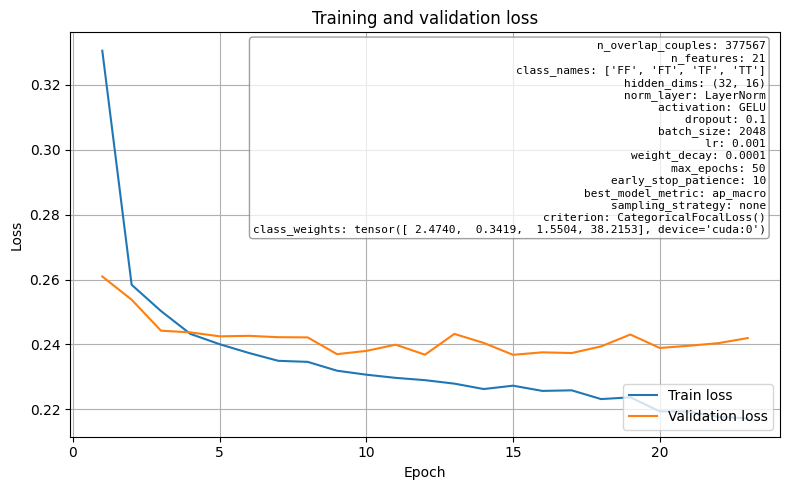

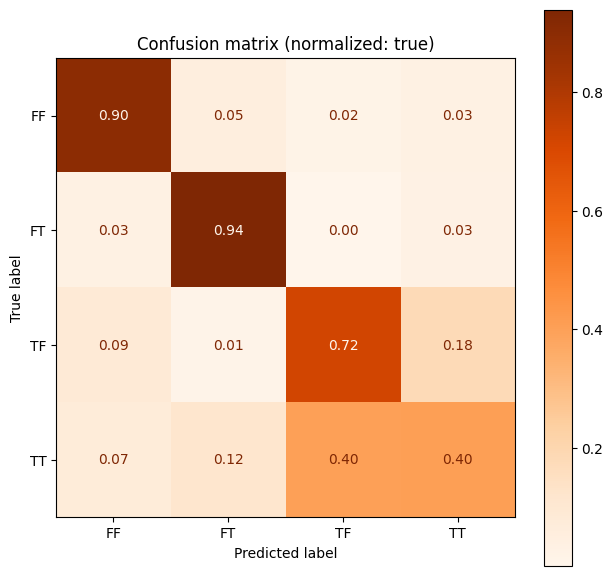

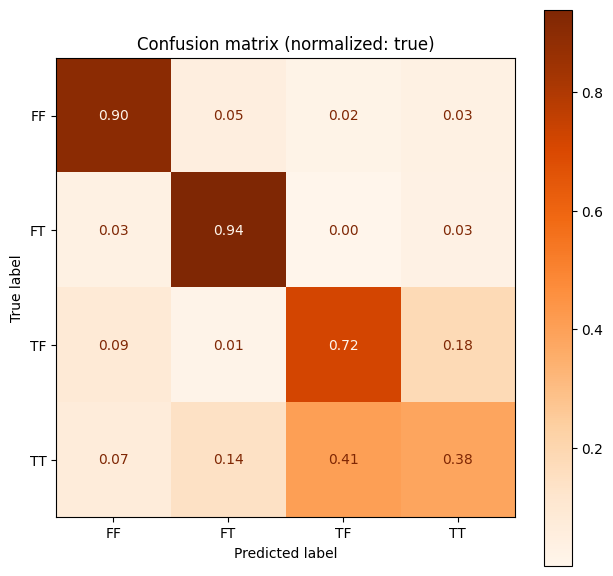

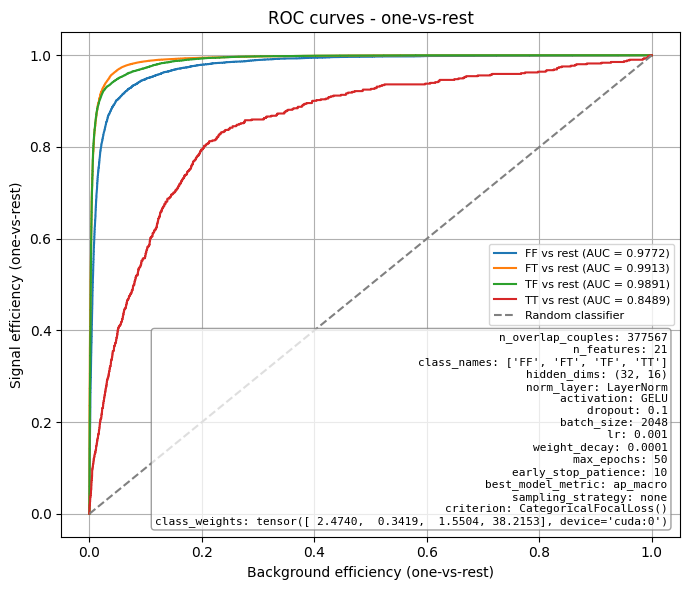

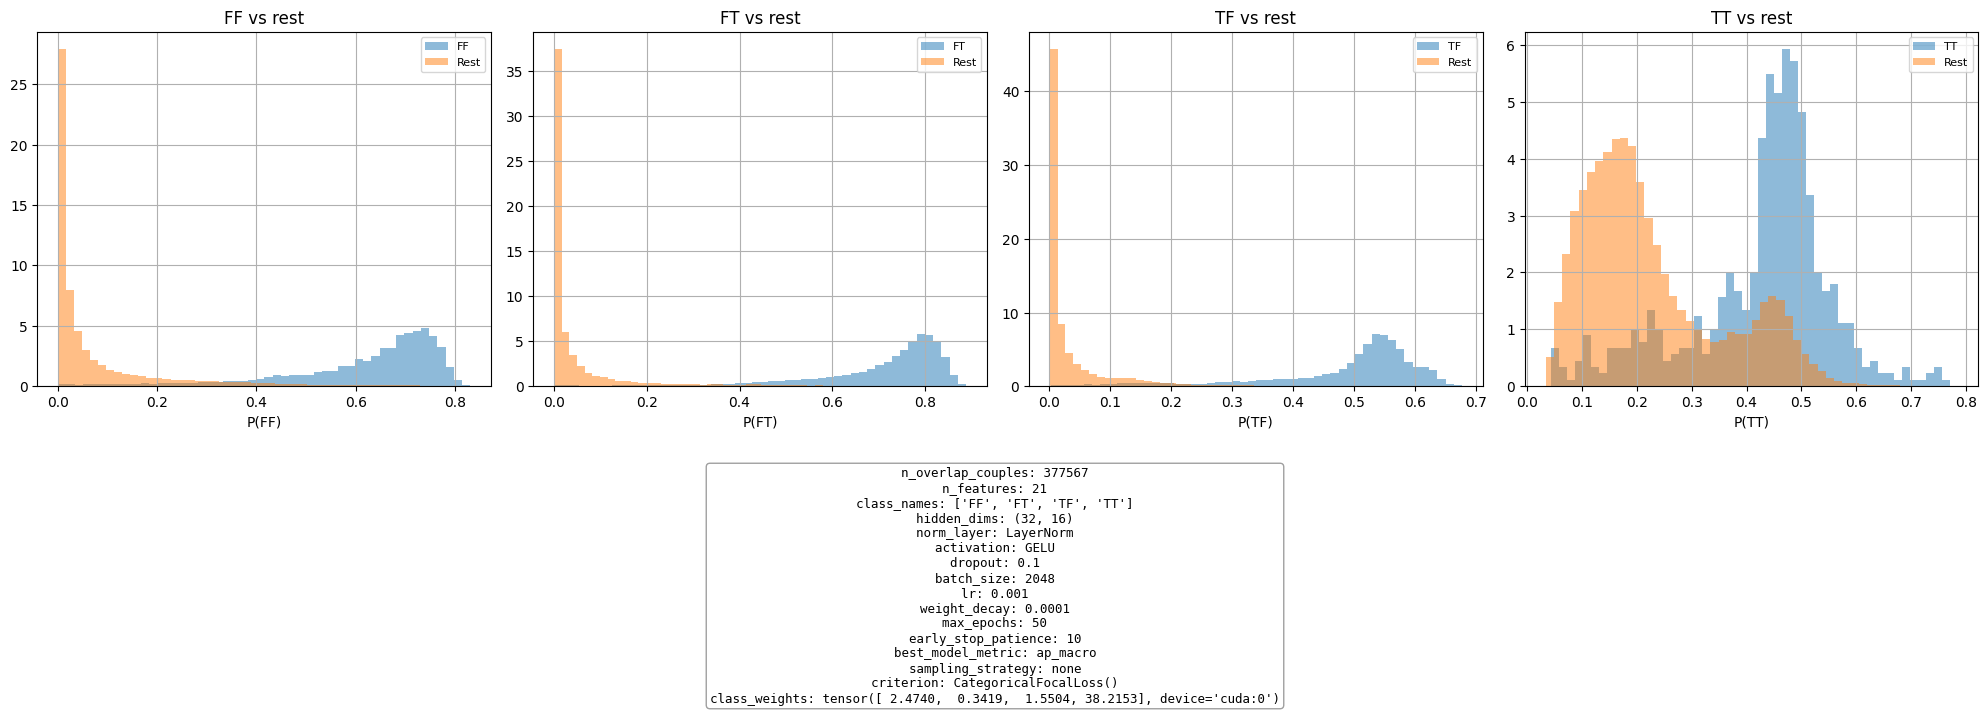

RUN METRICS REPORT - transformer_2layers_dmodel32_heads4_dropout0.1_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CategoricalFocalLoss()_weight_loss_True_sampling_strategy_none
run_tag: transformer_2layers_dmodel32_heads4_dropout0.1_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CategoricalFocalLoss()_weight_loss_True_sampling_strategy_none
timestamp: 2026-09-25T10:15:49

Dataset
-------
  input_dim: None
  n_train: None | n_val: None | n_test: None
  class balance train (frazione per classe): FF: 0.1011 | FT: 0.7311 | TF: 0.1612 | TT: 0.0065
  class balance test (frazione per classe): FF: 0.1004 | FT: 0.7302 | TF: 0.1619 | TT: 0.0076

Modello
-------
  name: SetTransformerTagger
  feature_groups: [[0, 1, 2, 3], [4, 5, 6, 7, 8, 9], [10, 11, 12, 13, 14, 15, 16, 17, 18], [19, 20]]
  num_classes: 4
  d_model: 32
  n_heads: 4
  n_layers: 2
  dropout: 0.1
  activ_func: GELU
  n_parametri_totali: 27844
  n_parametri_allenabili: 27844

Training
--------
  criterion: Categorical

In [33]:
eval_result = run_evaluation_suite(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    train_losses=train_losses,
    val_losses=val_losses,
    device=DEVICE,
    config=config,
    params=PLOT_PARAMS,
    run_name=RUN_TAG,
    run_tag=RUN_TAG,
    graphics_dir=GRAPHICS_DIR,
    repo_path=REPO_PATH_OVERLAP_RESOLVER,
    output_subdir=GIT_OUTPUT_DIR,
    class_names=CLASS_NAMES,
    working_point_targets=WORKING_POINT_TARGETS,
    atlas_style=ATLAS_STYLE,
    background_rejection_eff_range=BACKGROUND_REJECTION_EFF_RANGE,
    checkpoint_path=CHECKPOINT_PATH,
)

result = eval_result["push_result"]